In [1]:
import pandas as pd

ohlcv = pd.read_csv("silver_daily_ohlcv_2000_2025.csv")

ohlcv.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,-0.0090,0.0078,0.1511
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,-0.0930,0.0236,0.4649
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,0.0432,0.0076,0.1472
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,0.0826,0.0168,0.3225
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,0.0540,0.0066,0.1251


In [2]:
ohlcv['Date'] = pd.to_datetime(ohlcv['Date'])

ohlcv.set_index('Date', inplace=True)

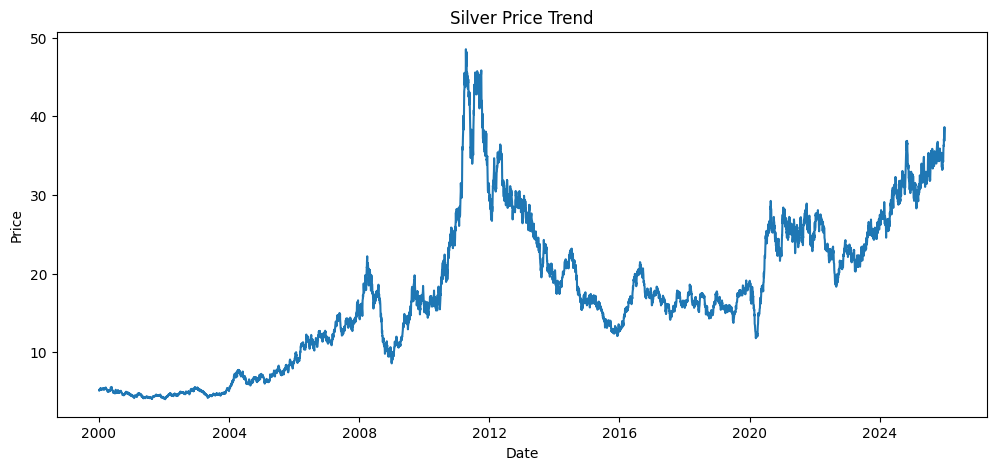

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ohlcv['Close'])

plt.title("Silver Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ohlcv['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.306166745299514
p-value: 0.6263463188186214


<Axes: xlabel='Date'>

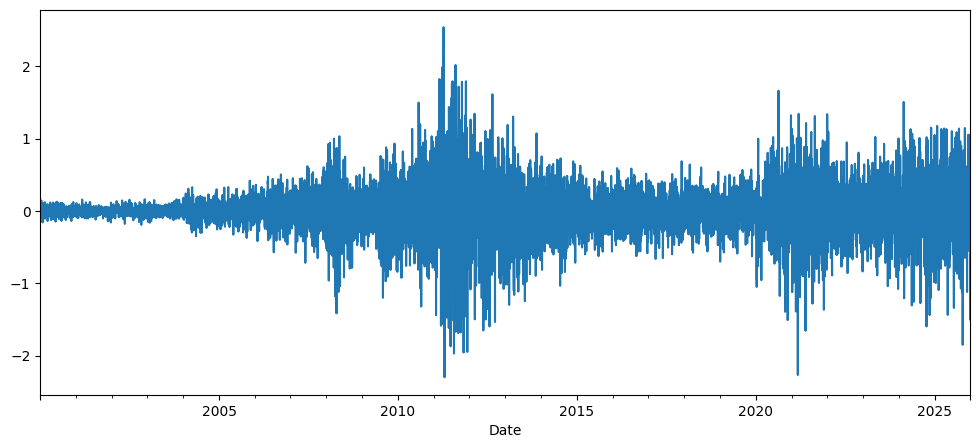

In [5]:
ohlcv['Close_Diff'] = ohlcv['Close'].diff()

ohlcv['Close_Diff'].dropna().plot(
    figsize=(12,5)
)

In [6]:
result = adfuller(
    ohlcv['Close_Diff'].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -19.330837485953655
p-value: 0.0


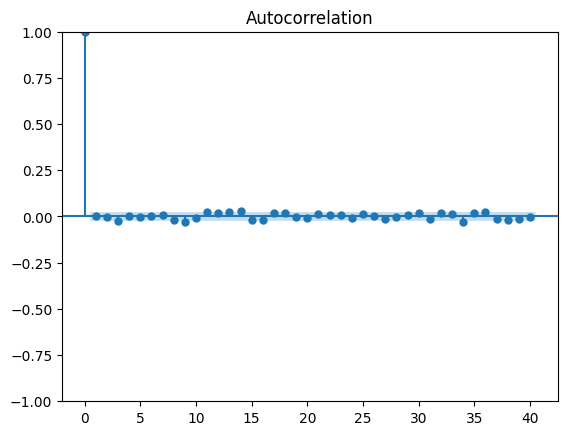

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    ohlcv['Close_Diff'].dropna(),
    lags=40
)

plt.show()

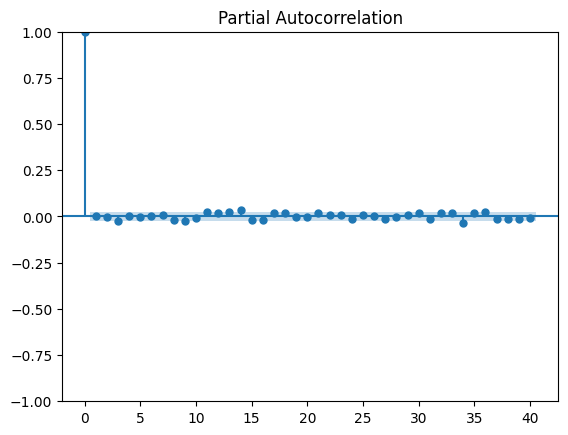

In [8]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    ohlcv['Close_Diff'].dropna(),
    lags=40
)

plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    ohlcv['Close'],
    order=(5,1,0)
)

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 6783
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3114.215
Date:                Fri, 26 Jun 2026   AIC                           6240.430
Time:                        14:58:33   BIC                           6281.363
Sample:                    01-03-2000   HQIC                          6254.557
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0007      0.008      0.090      0.929      -0.015       0.017
ar.L2         -0.0039      0.008     -0.511      0.609      -0.019       0.011
ar.L3         -0.0231      0.008     -2.947      0.0

In [10]:
forecast = model_fit.forecast(
    steps=30
)

print(forecast)

2026-01-01    36.952380
2026-01-02    36.991946
2026-01-05    36.987927
2026-01-06    36.988186
2026-01-07    36.987314
2026-01-08    36.987606
2026-01-09    36.987561
2026-01-12    36.987584
2026-01-13    36.987573
2026-01-14    36.987576
2026-01-15    36.987575
2026-01-16    36.987575
2026-01-19    36.987575
2026-01-20    36.987575
2026-01-21    36.987575
2026-01-22    36.987575
2026-01-23    36.987575
2026-01-26    36.987575
2026-01-27    36.987575
2026-01-28    36.987575
2026-01-29    36.987575
2026-01-30    36.987575
2026-02-02    36.987575
2026-02-03    36.987575
2026-02-04    36.987575
2026-02-05    36.987575
2026-02-06    36.987575
2026-02-09    36.987575
2026-02-10    36.987575
2026-02-11    36.987575
Freq: B, Name: predicted_mean, dtype: float64


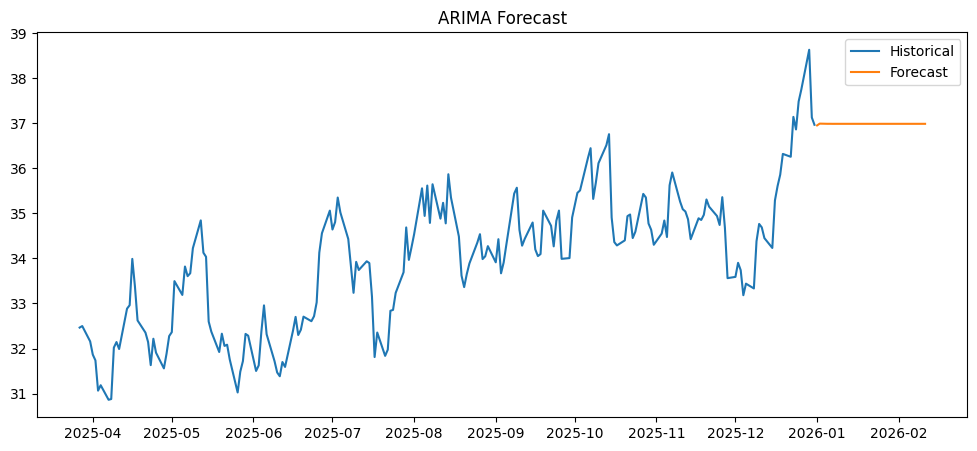

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    ohlcv['Close'].tail(200),
    label='Historical'
)

plt.plot(
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

In [12]:
import pickle

with open(
    'arima_model.pkl',
    'wb'
) as file:

    pickle.dump(
        model_fit,
        file
    )

In [13]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.1 MB/s eta 0:00:00


In [14]:
from pmdarima import auto_arima

auto_model = auto_arima(
    ohlcv['Close'],
    seasonal=False,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6243.219, Time=6.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6235.309, Time=2.76 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6237.307, Time=2.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6237.307, Time=2.97 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6234.324, Time=1.93 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6239.307, Time=4.85 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 21.009 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6783
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3116.162
Date:                Fri, 26 Jun 2026   AIC                           6234.324
Time:                        14:59:26   BIC                           6241.146
Sample:                    01-03-2000   HQIC                          6236.678
         

In [15]:
train = ohlcv['Close'][:-365]

test = ohlcv['Close'][-365:]

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train,
    order=(5,1,0)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


In [17]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [18]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test,
    forecast
)

print(mae)

2.1974956830519337


In [19]:
forecast_result = model_fit.get_forecast(
    steps=30
)

forecast = forecast_result.predicted_mean

conf_int = forecast_result.conf_int()

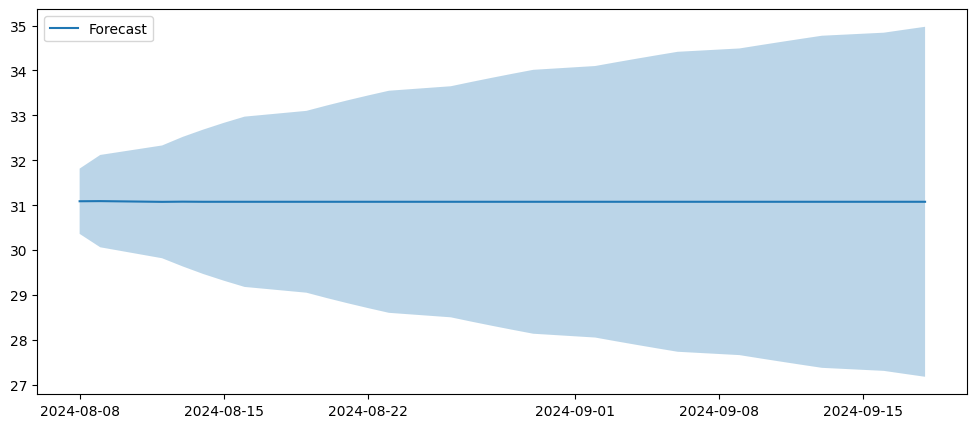

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast,
    label='Forecast'
)

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.show()

In [21]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [22]:
print(len(test))
print(len(forecast))

365
365


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 2.1974956830519337
RMSE: 2.7255294642115824
MAPE: 6.454282521421726


<Axes: title={'center': 'Residuals'}, xlabel='Date'>

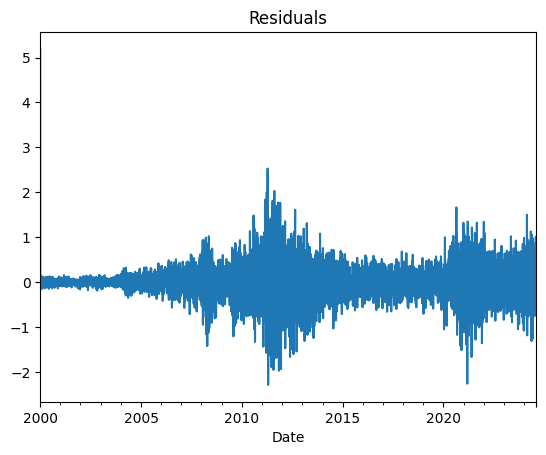

In [24]:
residuals = model_fit.resid

residuals.plot(
    title='Residuals'
)

<Axes: >

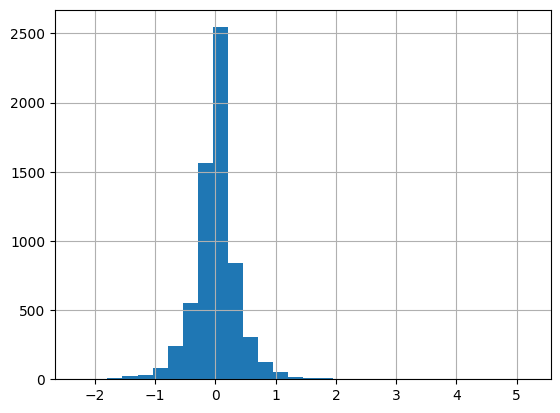

In [25]:
residuals.hist(
    bins=30
)

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(ljung)

     lb_stat  lb_pvalue
10  8.047518   0.624195


In [27]:
naive_forecast = test.shift(1)

mae_naive = mean_absolute_error(
    test[1:],
    naive_forecast[1:]
)

print(mae_naive)

0.45059038461538464


In [28]:
current_price = ohlcv['Close'].iloc[-1]

future_price = forecast.iloc[-1]

if future_price > current_price:
    print("BUY")

elif future_price < current_price:
    print("SELL")

else:
    print("HOLD")

SELL


In [29]:
ohlcv['Volatility_30'] = (
    ohlcv['Returns_Pct']
    .rolling(30)
    .std()
)

In [30]:
ohlcv['Peak'] = ohlcv['Close'].cummax()

ohlcv['Drawdown'] = (
    ohlcv['Close']
    -
    ohlcv['Peak']
) / ohlcv['Peak']

In [31]:
forecast = model_fit.forecast(steps=len(test))

In [32]:
import pandas as pd

pd.DataFrame({
    'ARIMA_Prediction': forecast
}).to_csv(
    'arima_predictions.csv',
    index=False
)

print("ARIMA predictions saved!")

ARIMA predictions saved!


In [33]:
pd.DataFrame({
    'Actual': test.values
}).to_csv(
    'actual_values_arima.csv',
    index=False
)

print("ARIMA actual values saved!")

ARIMA actual values saved!


In [ ]:
pd.DataFrame({
    'Actual': test.values,
    'ARIMA_Prediction': forecast
}).to_csv(
    'arima_results.csv',
    index=False
)

print("ARIMA results saved!")

ARIMA results saved!


In [34]:
import joblib

joblib.dump(
    model_fit,
    "arima_model.pkl"
)

print("ARIMA model saved!")

ARIMA model saved!


In [35]:
metrics = pd.DataFrame({
    'Metric': ['MAE'],
    'Value': [2.197]
})

metrics.to_csv(
    'arima_metrics.csv',
    index=False
)

print("ARIMA metrics saved!")

ARIMA metrics saved!


In [ ]:
print("ARIMA:", len(test))

ARIMA: 365


In [ ]:
print("Prophet:", len(test))

Prophet: 365


In [37]:
print("AIC :", model_fit.aic)
print("BIC :", model_fit.bic)
print("HQIC:", model_fit.hqic)

AIC : 5477.929844823675
BIC : 5518.530080810178
HQIC: 5491.981378466967


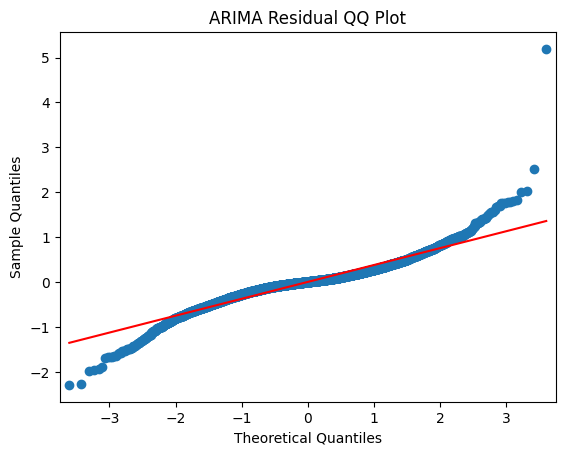

In [38]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot

qqplot(
    residuals,
    line='s'
)

plt.title(
    "ARIMA Residual QQ Plot"
)

plt.show()

In [39]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(
    residuals
)

print(
    "JB Statistic:",
    jb_stat
)

print(
    "P-Value:",
    jb_pvalue
)

JB Statistic: 24771.65364262707
P-Value: 0.0


In [40]:
import numpy as np
import pandas as pd

actual_direction = (
    test.diff() > 0
).astype(int)

forecast_direction = (
    pd.Series(forecast)
    .diff() > 0
).astype(int)

directional_accuracy = (
    actual_direction.iloc[1:].values
    ==
    forecast_direction.iloc[1:].values
).mean() * 100

print(
    "Directional Accuracy:",
    round(directional_accuracy,2),
    "%"
)

Directional Accuracy: 46.98 %


In [41]:
import numpy as np

max_error = np.max(
    np.abs(
        test.values -
        forecast.values
    )
)

print(
    "Maximum Absolute Error:",
    max_error
)

Maximum Absolute Error: 7.552545027378759


In [42]:
print(auto_model.order)

(0, 1, 0)


In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(0,1,0),
    seasonal_order=(1,0,1,5)
)

sarima_fit = sarima.fit()

print("ARIMA AIC :", model_fit.aic)
print("SARIMA AIC:", sarima_fit.aic)

print("ARIMA BIC :", model_fit.bic)
print("SARIMA BIC:", sarima_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA AIC : 5477.929844823675
SARIMA AIC: 5473.9186734853565
ARIMA BIC : 5518.530080810178
SARIMA BIC: 5494.218791478608


In [44]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

train_size = len(ohlcv) - 100

history = list(
    ohlcv['Close'][:train_size]
)

test_walk = ohlcv['Close'][train_size:]

predictions = []

for t in range(len(test_walk)):

    model = ARIMA(
        history,
        order=(0,1,0)
    )

    model_fit = model.fit()

    yhat = model_fit.forecast()[0]

    predictions.append(yhat)

    history.append(
        test_walk.iloc[t]
    )

mae_walk = mean_absolute_error(
    test_walk,
    predictions
)

print(
    "Walk Forward MAE:",
    mae_walk
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Walk Forward MAE: 0.4403930000000003


In [47]:
print(type(forecast))

<class 'numpy.ndarray'>


In [48]:
import pandas as pd

arima_predictions = pd.DataFrame({

    "Actual": test.values,

    "Prediction": forecast

})

arima_predictions.to_csv(
    "arima_predictions.csv",
    index=False
)

print("ARIMA Predictions Saved")

ARIMA Predictions Saved


In [50]:
arima_predictions.to_csv(

    "arima_predictions.csv",

    index=False

)

print("ARIMA Predictions Saved")

ARIMA Predictions Saved


In [51]:
import joblib

joblib.dump(

    model_fit,

    "arima_model.pkl"

)

print("ARIMA Model Saved")

ARIMA Model Saved


In [52]:
from google.colab import files

files.download("arima_predictions.csv")

files.download("arima_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>